In [1]:
#%matplotlib widget
import os as os
from mpl_toolkits.mplot3d import Axes3D
import rasterio
import matplotlib.pyplot as plt
from rasterio.transform import xy
import numpy as np
from pyproj import Geod
from scipy.interpolate import griddata
import json
import pandas as pd
from glob import glob
import re
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from pyproj import Geod
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import datetime
from datetime import timedelta



In [2]:
data_json = os.path.expanduser("~/moos/moos-ivp-ahoi/missions/multi-vehicle-domain/logs/241107-1648G-MASS-STAR/all_data/2024_11_08_mission_data_whole.json")
#2024_11_08_mission_data_whole.json

In [3]:

# Open and load the JSON data
with open(data_json, 'r') as file:
    data = json.load(file)

In [4]:
operating_directory = os.path.expanduser("~/moos/moos-ivp-ahoi/missions/multi-vehicle-domain/logs/241107-1648G-MASS-STAR/all_data/")
print(glob(f"{operating_directory}/*/LOG*"))

['/Users/raymondturrisi/moos/moos-ivp-ahoi/missions/multi-vehicle-domain/logs/241107-1648G-MASS-STAR/all_data/241107-1659P-NUDE-BUTT/LOG_SEASCOUT-00_7_11_2024_____17_00_03', '/Users/raymondturrisi/moos/moos-ivp-ahoi/missions/multi-vehicle-domain/logs/241107-1648G-MASS-STAR/all_data/241107-1723S-OPEN-LUIS/LOG_SEASCOUT-00_7_11_2024_____17_23_20', '/Users/raymondturrisi/moos/moos-ivp-ahoi/missions/multi-vehicle-domain/logs/241107-1648G-MASS-STAR/all_data/241107-1712V-ZANY-SLUG/LOG_SEASCOUT-00_7_11_2024_____17_13_04', '/Users/raymondturrisi/moos/moos-ivp-ahoi/missions/multi-vehicle-domain/logs/241107-1648G-MASS-STAR/all_data/241107-1703N-MALE-OVAL/LOG_SEASCOUT-00_7_11_2024_____17_03_50']


In [5]:

ss_log_dir = glob(f"{operating_directory}/*/LOG*")

not_include = ["RawGyro", "QuaternionAttitude", "RawMag", "GpsTimestamp"]
for path in ss_log_dir:
    directory, match = path.split("/")[0:-1], path.split("/")[-1]
    directory = os.path.join("/",*directory)
    if "LOG_SEASCOUT-00_3_11_2024_____16_26_47" in directory:
        continue
    if match in data.keys():
        #print(f"Match: {match}")
        path_for_run = directory
        csv_files = glob(f"{path_for_run}/*.csv")
        data[match]["data_csv"] = {}
        for csv_file in csv_files:
            if csv_file is None:
                continue
            csv_fname = csv_file.split("/")[-1]
            if "ahoi" in csv_fname:
                data[match]["data_csv"]["ahoi_ranges"] = pd.read_csv(csv_file)
            else:
                # Regular expression to match the date pattern
                date_pattern = r"\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}_"
                # Search for the date in the string
                date = re.search(date_pattern, csv_fname)
                if date is None:
                    continue 
                date = date.group().replace(".csv","")
                key = csv_fname.replace(date,"").replace(".csv","")
                # print(f"Statement: {date}")
                # print(f"Filename: {csv_file}")
                # print(f"Key: {key}")
                if any([elem in key for elem in not_include]):
                    continue
                # print(f"Statement: {date}")
                # print(f"Filename: {csv_file}")
                # print(f"Key: {key}")
                # print()
                data[match]["data_csv"][key] = pd.read_csv(csv_file)
            


In [6]:
skip_in_moos = {
    "LOGGER_DIRECTORY", "DB_EVENT", "APPCAST", "APPCAST_REQ", "PHI_HOST_IP", "REALMCAST_CHANNELS", "DB_TIME",
    "DB_UPTIME", "DB_CLIENTS", "DB_QOS", "PMARINEVIEWER_PID", "HELM_MAP_CLEAR", "PMV_CONNECT",
    "PROC_WATCH_TIME_WARP", "PROC_WATCH_EVENT", "PROC_WATCH_SUMMARY", "PROC_WATCH_ALL_OK", "UPROCESSWATCH_ITER_LEN",
    "PHI_HOST_IP_ALL", "PHI_HOST_IP_VERBOSE", "PHI_HOST_PORT_DB", "PHI_HOST_INFO", "PHOSTINFO_ITER_LEN",
    "UFSB_QBRIDGE_VARS", "UFSB_NODE_COUNT", "UFLDSHOREBROKER_ITER_LEN", "PREALM_ITER_LEN", "APPCAST_REQ_SHORESIDE",
    "UFLDDELVE_ITER_LEN", "PMARINEVIEWER_ITER_GAP", "PMARINEVIEWER_ITER_LEN", "REGION_INFO", "APPCAST_REQ_ALL",
    "COLLISION_DETECT_PARAMS", "ENCOUNTER_TOTAL", "NEAR_MISS_TOTAL", "COLLISION_TOTAL", "APP_LOG", "UFLDCOLLISIONDETECT_ITER_LEN",
    "UXMS_937_ITER_GAP", "UXMS_937_ITER_LEN", "UFLDNODECOMMS_ITER_LEN", "PSHARE_INPUT_SUMMARY", "NODE_BROKER_PING",
    "PROC_WATCH_FULL_SUMMARY", "PSHARE_OUTPUT_SUMMARY", "PHOSTINFO_ITER_GAP", "UFLDSHOREBROKER_ITER_GAP", "UFLDDELVE_ITER_GAP",
    "UFLDNODECOMMS_ITER_GAP", "PREALM_ITER_GAP", "UPROCESSWATCH_ITER_GAP", "UFLDCOLLISIONDETECT_ITER_GAP", "PSHARE_CMD",
    "UFSB_BRIDGE_VARS", "NODE_PSHARE_VARS", "NODE_BROKER_ACK_BEN", "NODE_BROKER_VACK",
    "COLLISION_DETECT_PARAMS_BEN", "APPCAST_REQ_BEN", "NODE_REPORT_UNC", "HEARTBEAT", "MOOS_MANUAL_OVERRIDE_ALL",
    "IVPHELM_REGISTER", "PLOGGER_STATUS", "PLOGGER_CMD", "DB_VARSUMMARY", "NA", "DB_RWSUMMARY", "PHELMIVP_PID",
    "UPROCESSWATCH_STATUS", "PSHARE_STATUS", "UQUERYDB_STATUS", "IVPHELM_DOMAIN", "IVPHELM_MODESET", "PHELMIVP_STATUS",
    "PHOSTINFO_STATUS", "PNODEREPORTER_PID", "PNODEREPORTER_STATUS", "UFLDNODEBROKER_PID", "UFLDNODEBROKER_STATUS",
    "UFLDMESSAGEHANDLER_STATUS", "UMH_SUMMARY_MSGS", "ULOADWATCH_STATUS", "ULOADWATCH_ITER_LEN", "PNODEREPORTER_ITER_GAP",
    "PNODEREPORTER_ITER_LEN", "UFLDMESSAGEHANDLER_ITER_GAP", "UFLDMESSAGEHANDLER_ITER_LEN", "UQUERYDB_ITER_GAP",
    "UQUERYDB_ITER_LEN", "UFLDNODEBROKER_ITER_GAP", "PROC_WATCH_EVENT", "PROC_WATCH_SUMMARY", "PROC_WATCH_ALL_OK",
    "PROC_WATCH_FULL_SUMMARY", "PHELMIVP_ITER_GAP", "IVPHELM_CPU", "IVPHELM_STATE", "UMEMWATCH_STATUS", "IVPHELM_LIFE_EVENT",
    "IVPHELM_SUMMARY", "MOOS_DEBUG", "IVPHELM_ALLSTOP", "PBAR30_STATUS",
    "PREALM_STATUS", "PSSPIDV2_STATUS","INEOM9N_V0_STATUS", "IHBK_CV7_STATUS",
    "PNAVIGATOR_AHRS_STATUS", "ITRACKER650_STATUS", "UMEMWATCH_ITER_LEN",
    "IVPHELM_BHV_CNT", "IVPHELM_BHV_CNT_EVER", "BHV_STATUS", "IVPHELM_STATEVARS", "IVPHELM_COMPLETED_PENDING",
    "IVPHELM_BHV_IDLE", "IVPHELM_UPDATEVARS", "SPEED_DIFF", "BHV_WARNING", "ULOADWATCH_ITER_GAP", "DEPTH_SLACK",
    "DEPTH_DIFF", "IVPHELM_ITER", "HDG_DIFF", "IVPHELM_IPF_CNT", "IVPHELM_TOTAL_PCS_FORMED", "IVPHELM_TOTAL_PCS_CACHED",
    "IVPHELM_CREATE_CPU", "IVPHELM_LOOP_CPU", "PHELMIVP_ITER_LEN", "ITRACKER650_ITER_GAP",
    "ITRACKER650_ITER_LEN", "INEOM9N_V0_ITER_GAP", "INEOM9N_V0_ITER_LEN", "PBAR30_ITER_GAP", "IHBK_CV7_ITER_GAP", "IHBK_CV7_ITER_LEN",
    "PSSPIDV2_ITER_GAP",
    "PSSPIDV2_ITER_LEN", "PBAR30_ITER_LEN",
    "PHOSTINFO_ITER_GAP", "PNAVIGATOR_AHRS_ITER_GAP", "PNAVIGATOR_AHRS_ITER_LEN", "PREALM_ITER_GAP", "PREALM_ITER_LEN",
    "PAFTCTRLV1_STATUS",
    "SS_MISSION_ABORT", "PAFTCTRLV1_ITER_LEN",
    "PAFTCTRLV1_ITER_GAP", "UMEMWATCH_ITER_GAP", "PHELMIVP_MEM", "NODE_BROKER_PING_0", "TRACKER_ROLL", "TRACKER_PITCH",
    "TRACKER_YAW",
    "IVPHELM_BHV_ACTIVE", "BHV_IPF", "ANCHOR_6_POS_X",
    "ANCHOR_6_POS_Y", "ANCHOR_6_SEQ", "RANGE_6", "RANGE_6_SEQ", "LEG_1_ACTIVE", "LEG_2_ACTIVE", "IVPHELM_COMPLETED_COUNT",
    "LEG_3_ACTIVE", "LEG_4_ACTIVE", "LEG_5_ACTIVE", "PNR_EXTRAP_POS_GAP",
    "PNR_EXTRAP_HDG_GAP", "PNR_POST_GAP", "LEG_6_ACTIVE", "LEG_7_ACTIVE", "LEG_8_ACTIVE", "LEG_9_ACTIVE", "LEG_10_ACTIVE",
    "MOOS_MANUAL_OVERRIDE_ALL", "UPOKEDB_STATUS", "UMAC_996_STATUS", "PMARINEPIDV22_STATUS",
    "RETURN", "STATION_KEEP", "PDEADMANPOST_STATUS", "PCONTACTMGRV20_PID", "PCONTACTMGRV20_STATUS", "CONTACTS_RECAP", 
    "CONTACT_RANGES", "PCONTACTMGRV20_ITER_LEN", "UFLDNODEBROKER_ITER_LEN", "PDEADMANPOST_ITER_GAP", "PDEADMANPOST_ITER_LEN", 
    "IM300_STATUS", "M4_DEBUG", "IM300HEALTH_STATUS", "IM300HEALTH_ITER_LEN", "M3_DEBUG",
    "PMARINEPIDV22_ITER_GAP", "PMARINEPIDV22_ITER_LEN", "IM300_ITER_GAP", 
    "PYDIR_THRUST_L", "PYDIR_THRUST_R", "IM300_RAW_NMEA", "IM300_ITER_LEN", 
    "GPS_SATS", "PCONTACTMGRV20_ITER_GAP", "IM300HEALTH_ITER_GAP", "PID_STALE", "IM300_BAD_NMEA", "NODE_BROKER_ACK", 
    "PNR_MHASH", "MOOS_MANUAL_OVERRIDE", "MODE", "BHV_SETTINGS", "PID_HAS_CONTROL", "IVPHELM_BHV_RUNNING", "TURN_RATE", 
    "WPT_INDEX", "WPT_STAT", "WPT_ODO", "MISSION", "CYCLE_INDEX", "UFLDNODEBROKER_ITER_LEN"
}

printing = 0
filtered_data = data.copy()
for key in list(filtered_data.keys()):
    if printing:
        print(f"{key}")
    for datk in list(filtered_data[key].keys()):
        if printing:
            print(f"\t- {datk}")
        if "data" in datk:
            for k in list(filtered_data[key][datk].keys()):
                #print(f"\t\t- {k}")
                if k in skip_in_moos:
                    del filtered_data[key][datk][k]
                    continue
                    #print(f"Deleted: {k}")
                if printing:
                    print(f"\t\t- {k}")


In [38]:
filtered_data['LOG_SEASCOUT-00_7_11_2024_____17_03_50']['data']['NAV_LAT']

[[1731017033.6082451, '42.35843', 'iNeoM9N_V0'],
 [1731017033.6082451, '42.35843', 'iNeoM9N_V0'],
 [1731017034.509265, '42.35843', 'iNeoM9N_V0'],
 [1731017034.509265, '42.35843', 'iNeoM9N_V0'],
 [1731017036.511425, '42.35843', 'iNeoM9N_V0'],
 [1731017036.511425, '42.35843', 'iNeoM9N_V0'],
 [1731017038.413535, '42.35843', 'iNeoM9N_V0'],
 [1731017040.415775, '42.35843', 'iNeoM9N_V0'],
 [1731017041.717245, '42.35843', 'iNeoM9N_V0'],
 [1731017044.520405, '42.35844', 'iNeoM9N_V0'],
 [1731017048.524905, '42.35844', 'iNeoM9N_V0'],
 [1731017050.426985, '42.35845', 'iNeoM9N_V0'],
 [1731017052.5294251, '42.35845', 'iNeoM9N_V0'],
 [1731017054.531665, '42.35846', 'iNeoM9N_V0'],
 [1731017056.5341651, '42.35847', 'iNeoM9N_V0'],
 [1731017058.536405, '42.35849', 'iNeoM9N_V0'],
 [1731017060.538615, '42.35851', 'iNeoM9N_V0'],
 [1731017063.4432151, '42.35852', 'iNeoM9N_V0'],
 [1731017065.345815, '42.35854', 'iNeoM9N_V0'],
 [1731017067.448085, '42.35855', 'iNeoM9N_V0'],
 [1731017068.749615, '42.35855', 'i

In [7]:
filtered_data.keys()

dict_keys(['LOG_SHORESIDE_7_11_2024_____16_48_56', 'LOG_SEASCOUT-00_7_11_2024_____17_00_03', 'LOG_EVE_7_11_2024_____16_49_06', 'LOG_SEASCOUT-00_7_11_2024_____17_23_20', 'LOG_BEN_7_11_2024_____16_49_04', 'LOG_SEASCOUT-00_7_11_2024_____17_13_04', 'LOG_MAX_7_11_2024_____16_49_05', 'LOG_SEASCOUT-00_7_11_2024_____17_03_50'])

In [9]:
# 0 - timestamp
# 1 - data
# 2 - source
anchor_dataframes = {}

heron_logs = [log for log in filtered_data.keys() if 'SEASCOUT' not in log and 'SHORESIDE' not in log]

# Loop over all heron logs to create separate DataFrames for each vname
for heron_log in heron_logs:
    vname = heron_log.split("_")[1].lower()
    node_report_data = []
    
    # Extract NODE_REPORT_LOCAL data for each vname
    for entry in filtered_data[heron_log]["data"]['NODE_REPORT_LOCAL']:
        nr_data = {k.lower(): (lambda x: float(x) if x.replace('.', '', 1).isdigit() else x)(v) 
                   for elem in entry[1].split("|") for k, v in [elem.split("=")]}
        nr_data["time"] = float(entry[0])
        node_report_data.append(nr_data)
    
    # Create a DataFrame for the current vname
    anchor_df = pd.DataFrame(node_report_data)
    anchor_df["time_since_epoch"] = anchor_df["time"]
    anchor_df["t_mission"] = anchor_df["time_since_epoch"] - anchor_df["time_since_epoch"].iloc[0]
    anchor_df.set_index("time_since_epoch", inplace=True)
    
    # Convert specified columns to numeric
    anchor_df[['x', 'y', 'spd', 'time']] = anchor_df[['x', 'y', 'spd', 'time']].apply(pd.to_numeric)
    
    # Store the DataFrame in the dictionary
    anchor_dataframes[vname] = anchor_df

# Display the dictionary keys to verify the mapping
print(anchor_dataframes.keys())



dict_keys(['eve', 'ben', 'max'])


In [10]:
# Start with an initial empty DataFrame for merging
one_big_anchor_df = pd.DataFrame()

# Iterate over each vname and DataFrame in the dictionary
for vname, df in anchor_dataframes.items():
    # Add suffix to each column name (except index)
    df_with_suffix = df.add_suffix(f'_{vname}')
    df_with_suffix.index = df.index  # Ensure the index remains as the time_since_epoch
    
    # Merge with the main DataFrame using 'outer' join
    if one_big_anchor_df.empty:
        one_big_anchor_df = df_with_suffix  # Initialize with the first DataFrame
    else:
        one_big_anchor_df = one_big_anchor_df.join(df_with_suffix, how='outer')
    
# Fill forward all NaN values and drop duplicate rows
one_big_anchor_df.ffill(inplace=True)
one_big_anchor_df.drop_duplicates(inplace=True)
one_big_anchor_df.dropna(inplace=True)

# Display the head of the final merged DataFrame to verify
one_big_anchor_df.head()

,name_eve,x_eve,y_eve,spd_eve,hdg_eve,type_eve,mode_eve,allstop_eve,time_eve,length_eve,...,y_max,spd_max,hdg_max,type_max,mode_max,allstop_max,time_max,length_max,index_max,t_mission_max
time_since_epoch,,,,,,,,,,,,,,,,,,,,,
1.731016e+09,eve,10.79,0.61,0.00,329.76,kayak,PARK,ManualOverride,1.731016e+09,4.0,...,0.80,0.01,213.77,kayak,PARK,ManualOverride,1.731016e+09,4.0,1.0,3.00447
1.731016e+09,eve,10.79,0.61,0.00,329.76,kayak,PARK,ManualOverride,1.731016e+09,4.0,...,0.80,0.01,213.77,kayak,PARK,ManualOverride,1.731016e+09,4.0,1.0,3.00447
1.731016e+09,eve,10.79,0.61,0.00,329.76,kayak,PARK,ManualOverride,1.731016e+09,4.0,...,0.85,0.01,213.77,kayak,PARK,ManualOverride,1.731016e+09,4.0,2.0,6.01027
1.731016e+09,eve,10.80,0.59,0.01,329.64,kayak,PARK,ManualOverride,1.731016e+09,4.0,...,0.85,0.01,213.77,kayak,PARK,ManualOverride,1.731016e+09,4.0,2.0,6.01027
1.731016e+09,eve,10.80,0.59,0.01,329.64,kayak,PARK,ManualOverride,1.731016e+09,4.0,...,0.85,0.01,213.77,kayak,PARK,ManualOverride,1.731016e+09,4.0,2.0,6.01027


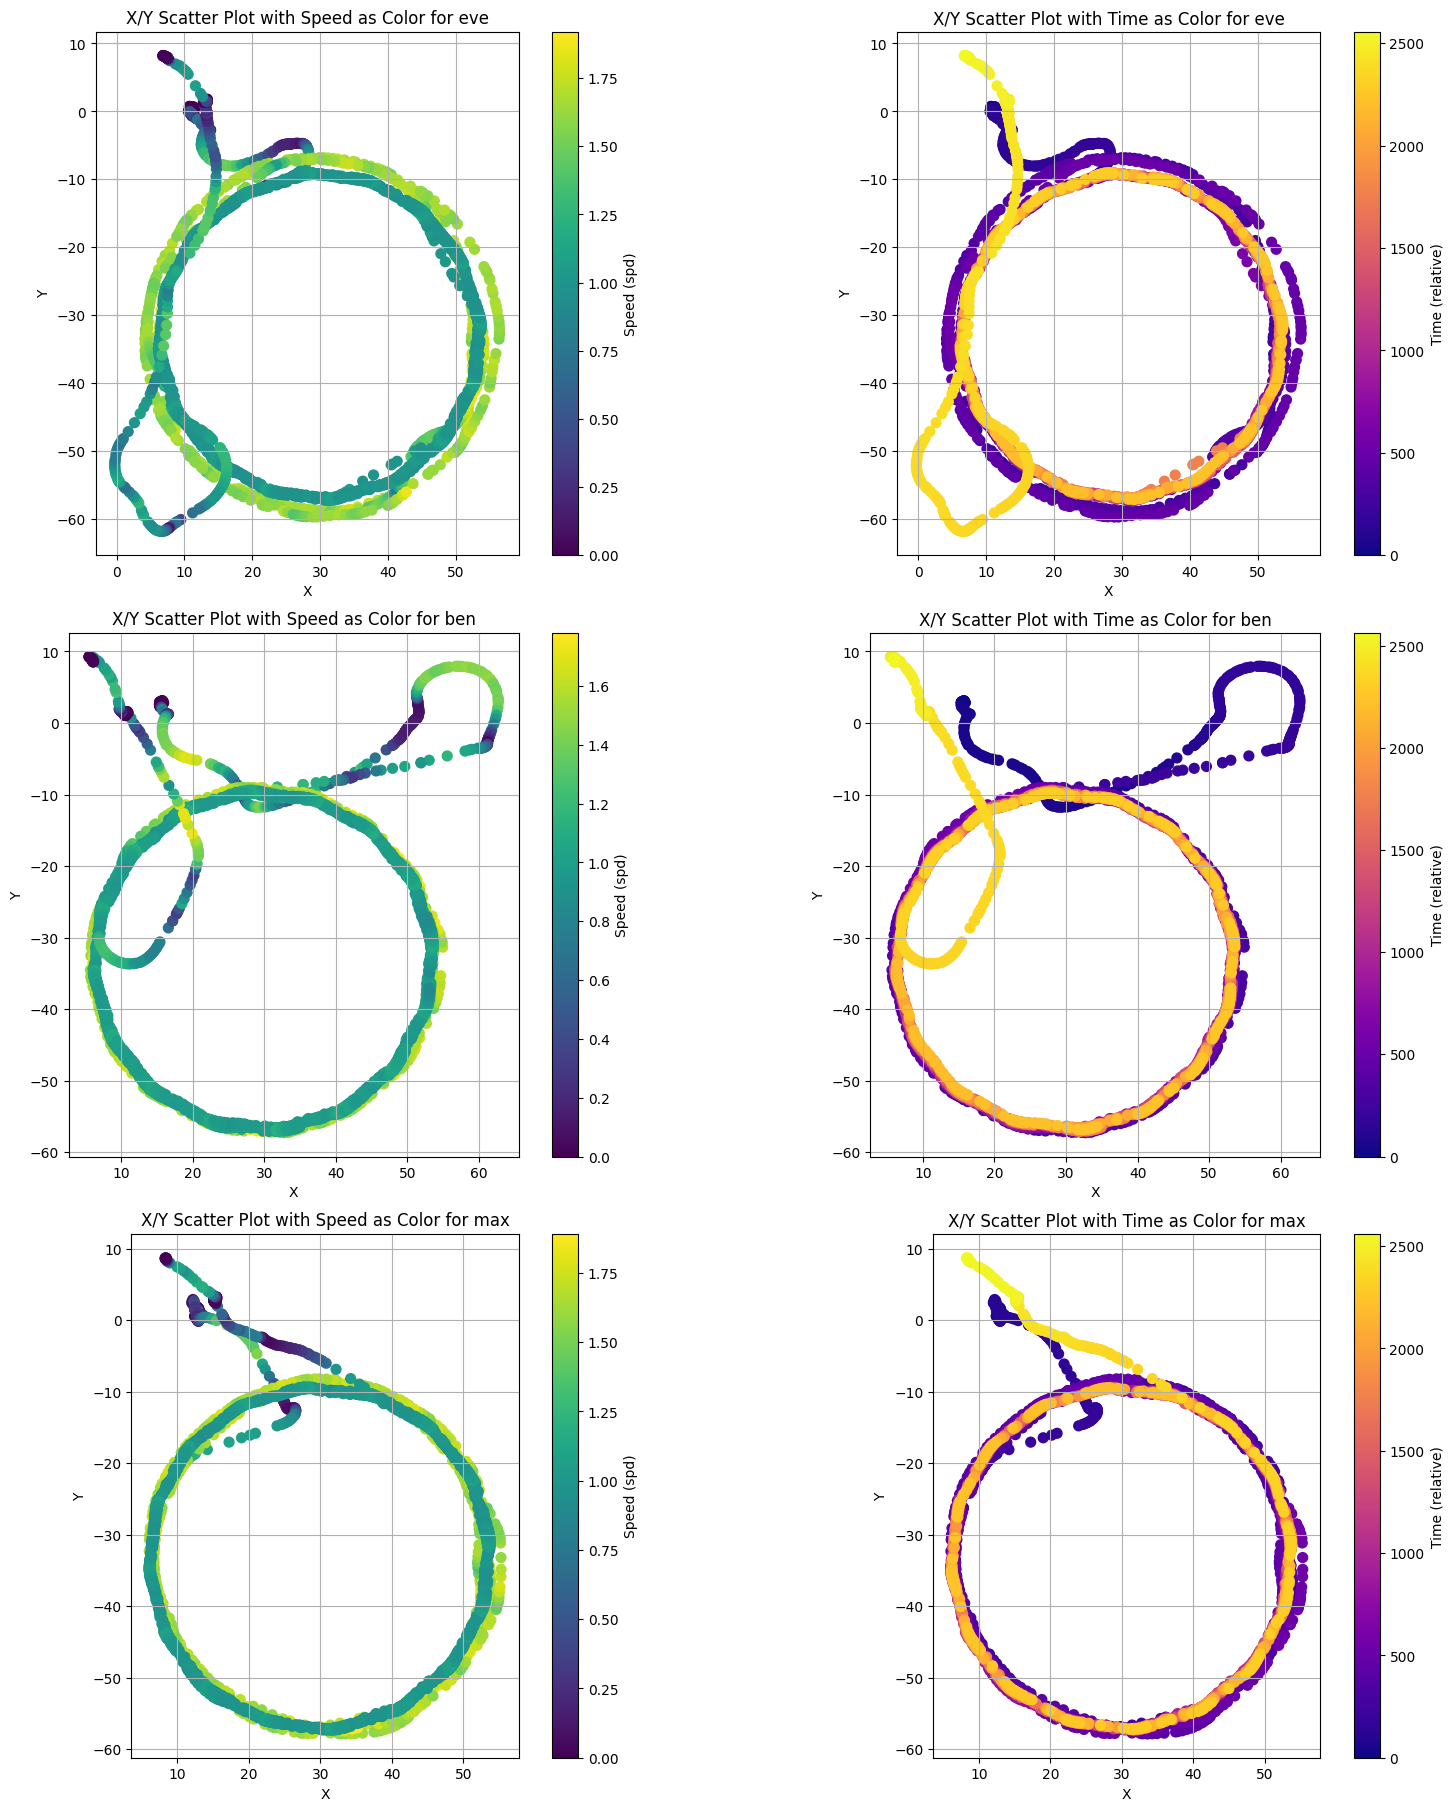

In [11]:
# Create a figure with subplots for each anchor DataFrame
num_anchors = len(anchor_dataframes)
fig, axes = plt.subplots(num_anchors, 2, figsize=(16, 6 * num_anchors), constrained_layout=True)

# Ensure axes are a 2D array even if there's only one anchor for consistent indexing
if num_anchors == 1:
    axes = [axes]

# Iterate over each vname and corresponding DataFrame
for i, (vname, anchor_df) in enumerate(anchor_dataframes.items()):
    # Scatter plot for speed (spd) as color
    scatter1 = axes[i][0].scatter(anchor_df['x'], anchor_df['y'], c=anchor_df['spd'], cmap='viridis', s=50)
    cbar1 = fig.colorbar(scatter1, ax=axes[i][0])
    cbar1.set_label('Speed (spd)')
    axes[i][0].set_xlabel('X')
    axes[i][0].set_ylabel('Y')
    axes[i][0].set_title(f'X/Y Scatter Plot with Speed as Color for {vname}')
    axes[i][0].set_aspect('equal')
    axes[i][0].grid(True)

    # Scatter plot for time (t_mission) as color
    scatter2 = axes[i][1].scatter(anchor_df['x'], anchor_df['y'], c=anchor_df['t_mission'], cmap='plasma', s=50)
    cbar2 = fig.colorbar(scatter2, ax=axes[i][1])
    cbar2.set_label('Time (relative)')
    axes[i][1].set_xlabel('X')
    axes[i][1].set_ylabel('Y')
    axes[i][1].set_title(f'X/Y Scatter Plot with Time as Color for {vname}')
    axes[i][1].set_aspect('equal')
    axes[i][1].grid(True)

# Show the plots
plt.show()

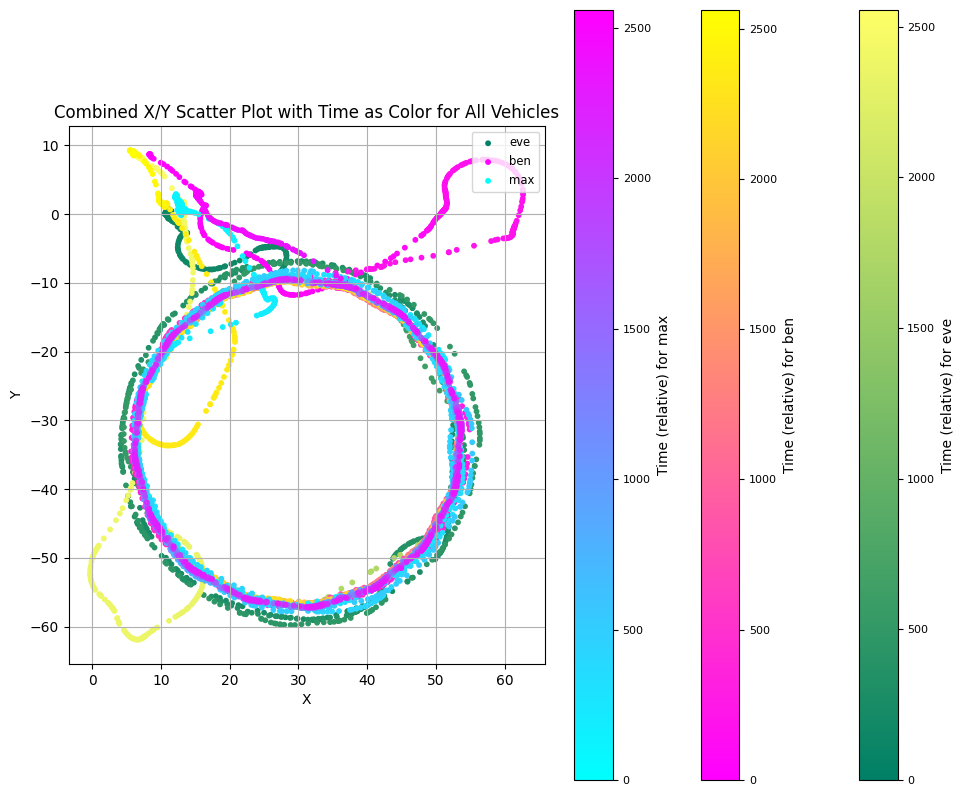

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Define a set of distinct colormaps for unique vehicle representation
colormaps = ['summer', 'spring', 'cool', 'magma', 'plasma', 'summer', 'autumn','winter']

# Create the figure for the combined scatter plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot each vehicle's data with a unique colormap and color bar
for i, (vname, anchor_df) in enumerate(anchor_dataframes.items()):
    cmap = colormaps[i % len(colormaps)]  # Cycle through colormaps if there are more vehicles than colormaps
    
    # Normalize the color map based on the time range
    norm = mcolors.Normalize(vmin=anchor_df['t_mission'].min(), vmax=anchor_df['t_mission'].max())
    
    # Scatter plot for each vehicle with time as color
    scatter = ax.scatter(
        anchor_df['x'], 
        anchor_df['y'], 
        c=anchor_df['t_mission'], 
        cmap=cmap, 
        norm=norm, 
        s=10,  # Small points for better visibility
        label=f'{vname}'
    )
    
    # Create an individual color bar for each vehicle with its specific colormap and normalization
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label(f'Time (relative) for {vname}', fontsize=10)
    cbar.ax.tick_params(labelsize=8)  # Smaller labels for better readability

# Set plot details
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Combined X/Y Scatter Plot with Time as Color for All Vehicles')
ax.set_aspect('equal')
ax.grid(True)
ax.legend(loc='upper right', fontsize='small')


In [13]:
from pyproj import Geod
import numpy as np

# Define the WGS84 ellipsoid model
geod = Geod(ellps="WGS84")

# Origin latitude and longitude (reference point for geodesic conversion)
LatOrigin = 42.358456
LongOrigin = -71.087589

# Iterate through each vehicle DataFrame and apply geodesic conversion
for vname, df in anchor_dataframes.items():
    converted_lats, converted_lons = [], []

    # Convert each point from Cartesian (X/Y) to Latitude/Longitude using geodesic conversion
    for x, y in zip(df['x'], df['y']):
        distance = np.sqrt(x**2 + y**2)  # Calculate distance in meters
        bearing = np.degrees(np.arctan2(x, y))  # Calculate bearing in degrees

        # Use geod.fwd to calculate the new lat/lon from the origin
        lon, lat, _ = geod.fwd(LongOrigin, LatOrigin, bearing, distance)
        converted_lats.append(lat)
        converted_lons.append(lon)
    
    # Add the converted latitude and longitude to the DataFrame
    df['lon'] = converted_lons
    df['lat'] = converted_lats

    # Update the dictionary with the modified DataFrame
    anchor_dataframes[vname] = df

# Now, each DataFrame in `anchor_dataframes` contains the new 'lat' and 'lon' columns


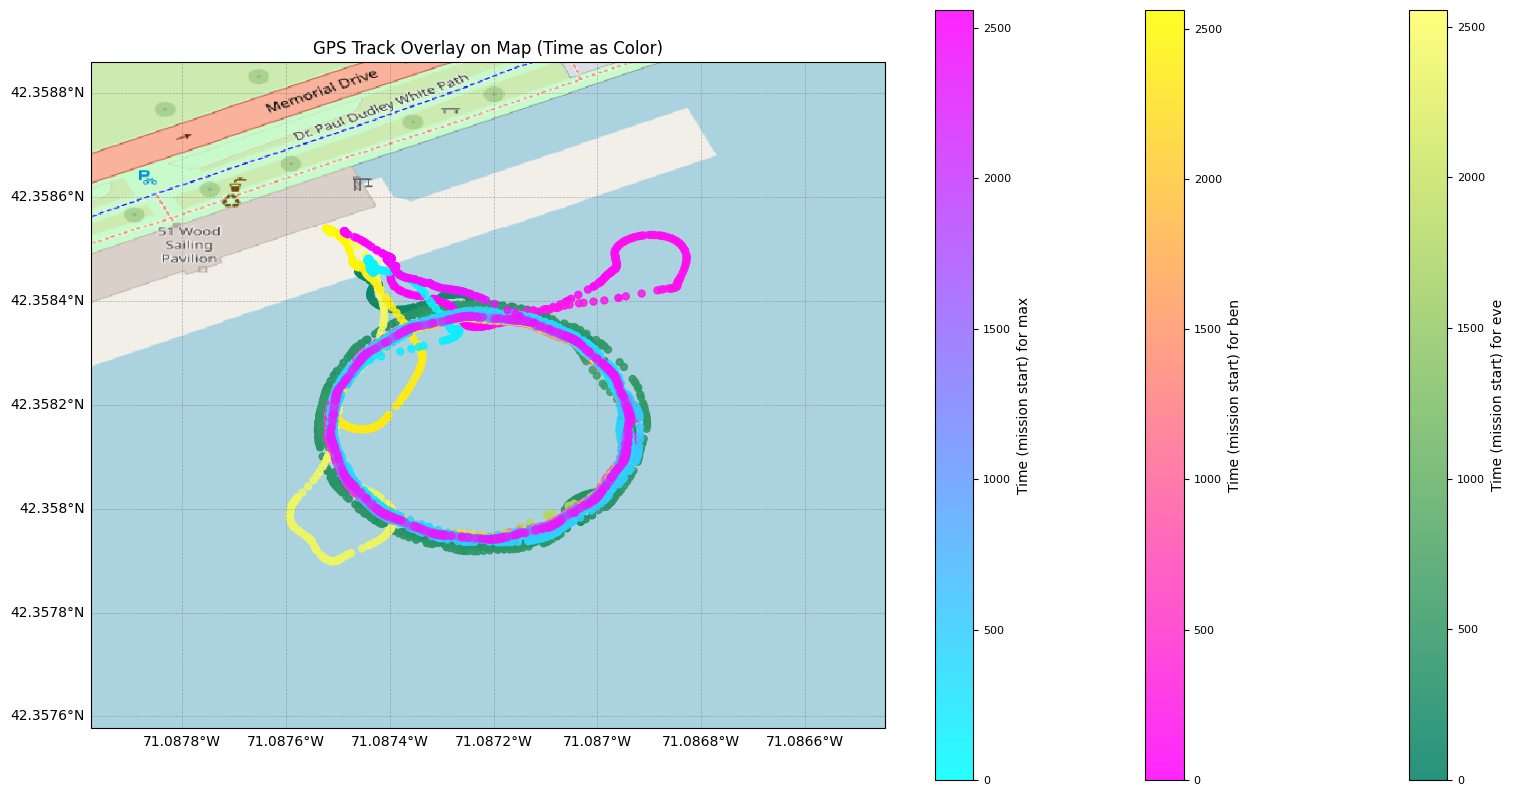

In [14]:
# Plot setup with OpenStreetMap as the background
fig, ax = plt.subplots(1, 1, figsize=(20, 10), subplot_kw={'projection': ccrs.PlateCarree()})
osm = cimgt.OSM()
ax.add_image(osm, 19)  # Adjust zoom level as needed

# Iterate over each vehicle DataFrame and plot the converted lat/lon track
for i, (vname, df) in enumerate(anchor_dataframes.items()):
    cmap = colormaps[i % len(colormaps)]  # Cycle through colormaps if there are more vehicles than colormaps

    # Scatter plot for each vehicle with time as color
    scatter = ax.scatter(
        df['lon'], 
        df['lat'], 
        c=df['t_mission'], 
        cmap=cmap, 
        s=25,  # Marker size for a clean look
        alpha=0.85,  # Transparency for overlap clarity
        transform=ccrs.PlateCarree(), 
        label=f"{vname}"
    )
    
    # Add a color bar for each vehicle's scatter plot
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical')
    cbar.set_label(f"Time (mission start) for {vname}")
    cbar.ax.tick_params(labelsize=8)  # Smaller labels for readability

# Set plot title and other details
ax.set_title("GPS Track Overlay on Map (Time as Color)")
ax.set_xlabel("Longitude", fontsize=12, labelpad=10)
ax.set_ylabel("Latitude", fontsize=12, labelpad=10)

# Add gridlines for geographic reference
gl = ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.5, color='gray', alpha=0.6)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Calculate the latitude and longitude range for all plotted points across vehicles
all_lats = [lat for df in anchor_dataframes.values() for lat in df['lat']]
all_lons = [lon for df in anchor_dataframes.values() for lon in df['lon']]
lat_min, lat_max = min(all_lats), max(all_lats)
lon_min, lon_max = min(all_lons), max(all_lons)

# Define padding as a fraction of the calculated range
padding_fraction = 0.5  # Adjust this value as needed
lat_padding = (lat_max - lat_min) * padding_fraction
lon_padding = (lon_max - lon_min) * padding_fraction

# Set the extent with calculated padding
ax.set_extent([lon_min - lon_padding, lon_max + lon_padding, 
               lat_min - lat_padding, lat_max + lat_padding])

plt.show()

In [15]:
def synchronize_data(filtered_data, ahoi_ranging, in_water_time, mission_complete_time, gps_data):
    ahoi_ranges = ahoi_ranging.copy()
    # print(ahoi_ranges.head())
    # Get individual dataframes and set time indices
    dvl_pdx_data = filtered_data['Tracker650_PDX'].copy()
    dvl_pdx_data["time"] = dvl_pdx_data["timeSinceEpoch"]
    navigator_ahrs_data = filtered_data['Navigator_AHRS'].copy()
    dvl_pdx_data.set_index('timeSinceEpoch', inplace=True)
    navigator_ahrs_data.set_index('TimeStamp', inplace=True)
    
    # Filter DVL data to mission timeframe
    #dvl_pdx_data = dvl_pdx_data[(dvl_pdx_data.index >= in_water_time) & (dvl_pdx_data.index <= mission_complete_time)]
    dvl_pdx_data.drop(columns=["angleDeltaRoll","angleDeltaPitch","angleDeltaYaw","utimeSinceBoot"],inplace=True)
    
    # Calculate time since mission start
    dvl_pdx_data['t_mission'] = dvl_pdx_data.index - dvl_pdx_data.index[0]
    
    # Add mask for DVL data
    dvl_pdx_data['mask'] = ~dvl_pdx_data['deltaX'].isna()
    
    # First join with navigator data and forward fill
    synced = dvl_pdx_data.join(navigator_ahrs_data[['Roll', 'Pitch', 'Yaw', 'Heading']], how='left')
    synced[['Roll', 'Pitch', 'Yaw', 'Heading']] = synced[['Roll', 'Pitch', 'Yaw', 'Heading']].ffill()
    
    # Filter by mask before GPS merge
    synced["mask"] = True
    
    # Now merge GPS data
    
    # print("here")
    # print(gps_data.head())
    # print()
    # Join with GPS data and forward fill
    synced = synced.join(gps_data, how='outer')
    synced[['nav_x_gps', 'nav_y_gps']] = synced[['nav_x_gps', 'nav_y_gps']].ffill()
    
    synced = synced[synced["mask"] == True].drop(columns="mask")
    
    # print("merged unique gps")
    # print(synced[["nav_x_gps", "nav_y_gps"]].head(30).drop_duplicates())

    # print("here 2")
    # print(synced.head())
    # print()
    
    # Now deal with the ahoi ranging data
    tof_pos_poll_df = ahoi_ranges[ahoi_ranges['event'] == 'TOF-POS-poll'].reset_index(drop=True)
    tof_pos_poll_df['time'] = tof_pos_poll_df['time_since_epoch']
    tof_pos_poll_df.set_index(['time_since_epoch'],inplace=True)

    tof_ack_df = ahoi_ranges[ahoi_ranges['event'] == 'TOF-ACK'].reset_index(drop=True)
    tof_ack_df['time'] = tof_ack_df['time_since_epoch']
    tof_ack_df.set_index(['time_since_epoch'],inplace=True)

    pos_ack_df = ahoi_ranges[ahoi_ranges['event'] == 'POS-ACK'].reset_index(drop=True)
    pos_ack_df['time'] = pos_ack_df['time_since_epoch']
    pos_ack_df.set_index(['time_since_epoch'],inplace=True)
    pos_ack_df["time_sent"] = pos_ack_df['time'] - (pos_ack_df['time.1']/1000.0)
    
    tof_pos_poll_df = tof_pos_poll_df.reset_index().rename(columns={'time_since_epoch': 'time_sent', 'event': 'tof_pos_poll_event'})
    tof_pos_poll_df.drop(columns=["pos_x", "pos_y", "distance", "time.1"], inplace=True)
    tof_ack_df = tof_ack_df.reset_index().rename(columns={'time_since_epoch': 'range_received', 'event': 'tof_ack_event', "time.1": "transmission_time_range_ms"})
    tof_ack_df.drop(columns=["target_id","pos_x","pos_y"], inplace=True)
    pos_ack_df = pos_ack_df.reset_index().rename(columns={'time_since_epoch': 'pos_received', 'event': 'pos_ack_event', "time.1": "transmission_time_ms"})
    pos_ack_df.drop(columns=["distance","target_id"], inplace=True)
    
    # Merge DataFrames based on sequence_number to create the final ahoi_ranges DataFrame
    ahoi_ranges = tof_pos_poll_df.merge(
        tof_ack_df[['sequence_number', 'range_received', 'transmission_time_range_ms', 'tof_ack_event','distance']], 
        on='sequence_number', how='outer'
    ).merge(
        pos_ack_df[['sequence_number', 'pos_received', 'transmission_time_ms', 'pos_x', 'pos_y', 'pos_ack_event']], 
        on='sequence_number', how='outer'
    )
    #ahoi_ranges.drop(columns=["tof_pos_poll_event", "tof_ack_event", "pos_ack_event"], inplace=True)
    ahoi_ranges = ahoi_ranges.rename(columns={'time': 'time_since_epoch'})
    
    ahoi_ranges = ahoi_ranges[(ahoi_ranges['time_since_epoch'] >= in_water_time) & 
                            (ahoi_ranges['time_since_epoch'] <= mission_complete_time)]
    
    ahoi_ranges.rename(columns={"time": "time_ahoi"}, inplace=True)
    
    synced['mask'] = True

    ahoi_ranges = ahoi_ranges.rename(columns={'time_since_epoch': 'time'}).set_index('time')

    synced = synced.set_index('time', drop=False)  # Ensure `synced` is indexed by `time`
    synced = synced.join(ahoi_ranges, how='outer').sort_index()

    ahoi_cols = ahoi_ranges.columns
    synced[ahoi_cols] = synced[ahoi_cols].ffill()

    synced = synced[synced['mask'] == True]

    synced = synced.drop(columns=['mask'])

    return synced, ahoi_ranges

def propagate_dvl_positions(sync_data):
    """
    Compute world-frame positions from DVL data and propagate over time using AHRS data.
    """
    # Calculate time and velocities
    sync_data['dT'] = sync_data['duT']/1000000
    sync_data['surge'] = sync_data['deltaX']/sync_data['dT']
    sync_data['sway'] = sync_data['deltaY']/sync_data['dT']
    sync_data['heave'] = sync_data['deltaZ']/sync_data['dT']
    
    # Convert angles to radians
    sync_data['roll_rad'] = np.radians(sync_data['Roll'])
    sync_data['pitch_rad'] = np.radians(sync_data['Pitch'])
    sync_data['heading_cart_rad'] = np.radians(450 - sync_data['Heading']) % (2 * np.pi)
    
    # Transform velocities to world frame
    world_velocities = sync_data.apply(transform_to_world, axis=1)
    sync_data[['x_dot', 'y_dot', 'z_dot']] = pd.DataFrame(world_velocities.tolist(), index=sync_data.index)
    
    # Get initial GPS position
    start_nav_x_gps = sync_data['nav_x_gps'].dropna().iloc[0]
    start_nav_y_gps = sync_data['nav_y_gps'].dropna().iloc[0]
    
    # Compute deltas and propagate positions
    sync_data['delta_x'] = sync_data['x_dot'] * sync_data['dT']
    sync_data['delta_y'] = sync_data['y_dot'] * sync_data['dT']
    sync_data['delta_z'] = sync_data['z_dot'] * sync_data['dT']
    
    # Propagate from GPS start
    sync_data['x_prop'] = sync_data['delta_x'].cumsum() + start_nav_x_gps
    sync_data['y_prop'] = sync_data['delta_y'].cumsum() + start_nav_y_gps
    sync_data['z_prop'] = sync_data['delta_z'].cumsum()
    
    return sync_data

def transform_to_world(row):
    """
    Apply rotation based on heading, pitch, and roll to transform velocities to the world frame.
    """
    R = rotation_matrix(row['roll_rad'], row['pitch_rad'], row['heading_cart_rad'])
    local_velocity = np.array([row['surge'], row['sway'], row['heave']])
    return R @ local_velocity

def rotation_matrix(roll, pitch, heading):
    """
    Generate rotation matrix based on roll, pitch, and heading angles.
    Adds small heading correction of 4.5 degrees as in reference code
    """
    R_x = np.array([[1, 0, 0], [0, np.cos(roll), -np.sin(roll)], [0, np.sin(roll), np.cos(roll)]])
    R_y = np.array([[np.cos(pitch), 0, np.sin(pitch)], [0, 1, 0], [-np.sin(pitch), 0, np.cos(pitch)]])
    
    #heading = heading - 10*np.pi/180.0  # Add 4.5 degree correction as in reference
    R_z = np.array([[np.cos(heading), -np.sin(heading), 0], [np.sin(heading), np.cos(heading), 0], [0, 0, 1]])
    
    return R_z @ R_y @ R_x

def add_geodetic_positions(data):
    """
    Convert Cartesian positions (both DVL propagated and GPS) to lat/lon based on the geodetic origin.
    """
    # Convert DVL propagated positions
    dvl_lats, dvl_lons = [], []
    for x, y in zip(data['x_prop'], data['y_prop']):
        dist = np.sqrt(x**2 + y**2)
        bearing = np.degrees(np.arctan2(x, y))
        lon, lat, _ = geod.fwd(LongOrigin, LatOrigin, bearing, dist)
        dvl_lats.append(lat)
        dvl_lons.append(lon)
    data['latitude_prop'] = dvl_lats
    data['longitude_prop'] = dvl_lons

    # Convert GPS x/y positions
    gps_lats, gps_lons = [], []
    for x, y in zip(data['nav_x_gps'], data['nav_y_gps']):
        dist = np.sqrt(x**2 + y**2)
        bearing = np.degrees(np.arctan2(x, y))
        lon, lat, _ = geod.fwd(LongOrigin, LatOrigin, bearing, dist)
        gps_lats.append(lat)
        gps_lons.append(lon)
    data['latitude'] = gps_lats
    data['longitude'] = gps_lons
    
    return data

In [58]:
#stamen_terrain = cimgt.Stamen('terrain')
#esri_imagery = cimgt.QuadtreeTiles()

def mission_summary_plot(sync_data, anchor_dataframes, ahoi_ranging, show_plot=True):
    # Define colormaps for each vehicle for better visual distinction
    colormaps = ['summer', 'spring', 'cool', 'magma', 'plasma', 'autumn', 'winter', 'cividis']
    
    # Clean data - remove any NaN or Inf values
    # sync_data = sync_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['longitude', 'latitude'])
    
    # Synchronize anchor data to match the mission time frame
    mission_start_time = sync_data['t_mission'].min()
    mission_end_time = sync_data['t_mission'].max()
    
    # Create figure with controlled spacing
    fig = plt.figure(figsize=(20, 10))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    
    # Use OpenStreetMap as the map background
    osm = cimgt.OSM()
    ax.add_image(osm, 19)  # Adjust zoom level as needed
    
    # Plot DVL propagated track
    scatter_dvl = ax.scatter(sync_data["longitude_prop"], 
                             sync_data["latitude_prop"], 
                             c=sync_data['t_mission'], 
                             cmap='Blues', 
                             s=20,  # Marker size
                             transform=ccrs.PlateCarree(), 
                             label="DVL Track")
    
    # Plot Anchor Data for each vehicle
    for i, (vname, anchor_df) in enumerate(anchor_dataframes.items()):
        cmap = colormaps[i % len(colormaps)]  # Cycle through colormaps for better contrast
        
        scatter_anchor = ax.scatter(anchor_df['lon'], 
                                    anchor_df['lat'], 
                                    c=anchor_df['t_mission'], 
                                    cmap=cmap, 
                                    s=20,  # Adjusted marker size
                                    transform=ccrs.PlateCarree(), 
                                    label=f"Anchor Data ({vname})")
        
        # Add color bar for each vehicle's anchor data
        cbar = fig.colorbar(scatter_anchor, ax=ax, orientation='vertical')
        cbar.set_label(f"Time (mission start) for {vname}")
        cbar.ax.tick_params(labelsize=8)  # Smaller labels for readability

    # Find first unique occurrences of pos_x and pos_y and create a new DataFrame
    unique_pos_df = sync_data.dropna(subset=['pos_x', 'pos_y']).drop_duplicates(subset=['pos_x', 'pos_y'])
    unique_pos_df = unique_pos_df.dropna(subset=['longitude_prop', 'latitude_prop'])  # Ensure long/lat propagation
    
    # Plot these unique pos_x, pos_y points as green dots on the DVL propagated track
    ax.scatter(unique_pos_df["longitude_prop"], 
               unique_pos_df["latitude_prop"], 
               color='springgreen', 
               s=10,  # Adjusted marker size
               marker='o', 
               transform=ccrs.PlateCarree(), 
               label="Acoustic Pings")
    
    # Plot GPS track
    gps_data = sync_data[["latitude", "longitude", "latitude_prop", "longitude_prop", "nav_x_gps", "nav_y_gps", "x_prop", "y_prop"]].dropna()
    scatter_gps = ax.scatter(gps_data["longitude"], 
                             gps_data["latitude"], 
                             color='red', 
                             s=20,  # Marker size
                             transform=ccrs.PlateCarree(), 
                             label="GPS Track")
    ax.legend()

    # Calculate bounds
    all_lats = [lat for df in anchor_dataframes.values() for lat in df['lat']] + sync_data['latitude'].tolist() + sync_data['latitude_prop'].tolist()
    all_lons = [lon for df in anchor_dataframes.values() for lon in df['lon']] + sync_data['longitude'].tolist() + sync_data['longitude_prop'].tolist()
    
    lat_min = min(all_lats)
    lat_max = max(all_lats)
    lon_min = min(all_lons)
    lon_max = max(all_lons)
    
    # Calculate center and range
    lat_center = (lat_max + lat_min) / 2
    lon_center = (lon_max + lon_min) / 2
    range_max = max(lat_max - lat_min, lon_max - lon_min)
    
    # Set equal padding in both directions
    padding = range_max * 0.2
    ax.set_extent([lon_center - range_max/2 - padding, 
                   lon_center + range_max/2 + padding,
                   lat_center - range_max/2 - padding, 
                   lat_center + range_max/2 + padding])
    
    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    
    # Add title and legend
    ax.set_title("Mission Description Summary")
    #ax.legend(loc='lower right')
    
    # Enforce aspect ratio
    ax.set_aspect('equal', adjustable='box')
    
    # Adjust layout
    plt.subplots_adjust(right=0.9)  # Room for colorbars
    
    plt.show()
    
    # Second plot: Range error plot
    fig2 = plt.figure(figsize=(20, 5))
    ax2 = fig2.add_subplot(111)
    range_data = sync_data[['pos_x', 'pos_y', 'x_prop', 'y_prop', 'distance','t_mission','sequence_number']].dropna()
    range_data['range_error'] = ((range_data['pos_x'] - range_data['x_prop'])**2 + 
                                 (range_data['pos_y'] - range_data['y_prop'])**2)**0.5 - range_data['distance']

    # Plot range error vs. mission time
    range_data = range_data.drop_duplicates("sequence_number")
    ax2.scatter(range_data['t_mission'], range_data['range_error'], label="Range Error", color='purple')
    ax2.set_xlabel("Time (t_mission)")
    ax2.set_ylabel("Range Error (meters)")
    ax2.set_title("Range Error between Propagated Trajectory and Anchor Position")
    ax2.legend()
    ax2.grid()

    plt.tight_layout()
    plt.show()
        
    return

In [59]:
sync_data

,duT,deltaX,deltaY,deltaZ,latestConfidence,mode,pitch,roll,yaw,standoff,...,delta_x,delta_y,delta_z,x_prop,y_prop,z_prop,latitude_prop,longitude_prop,latitude,longitude
time,,,,,,,,,,,,,,,,,,,,,
1.731017e+09,200000.0,0.00000,0.00000,0.00000,0.0,0.0,6.4,3.9,0.0,0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.731017e+09,200000.0,0.00000,0.00000,0.00000,0.0,0.0,6.4,3.9,0.0,0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.731017e+09,200000.0,0.00000,0.00000,0.00000,0.0,0.0,6.4,3.9,0.0,0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.731017e+09,200000.0,0.00000,0.00000,0.00000,0.0,0.0,6.4,3.9,0.0,0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.358430,-71.086923
1.731017e+09,200000.0,0.00000,0.00000,0.00000,0.0,0.0,6.4,3.9,0.0,0.1,...,0.000000,0.000000,0.000000,54.906150,-2.908410,0.000000,42.358430,-71.086923,42.358430,-71.086923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.731017e+09,100000.0,0.03489,0.00596,0.00469,72.0,3.0,-3.0,-24.1,0.0,6.6,...,0.006336,-0.035107,0.001487,130.649306,-234.463977,4.288823,42.356345,-71.086003,42.358551,-71.086673
1.731017e+09,100000.0,0.03528,0.00483,0.00602,72.0,3.0,-2.1,-22.9,0.0,6.6,...,0.005808,-0.035505,0.003149,130.655115,-234.499482,4.291972,42.356345,-71.086003,42.358551,-71.086673
1.731017e+09,100000.0,0.03416,0.00185,0.00382,69.0,3.0,-1.9,-22.4,0.0,6.6,...,0.002237,-0.034272,0.002314,130.657351,-234.533754,4.294286,42.356345,-71.086003,42.358551,-71.086673


In [60]:
sync_data[["latitude", "longitude", "latitude_prop", "longitude_prop", "nav_x_gps", "nav_y_gps", "x_prop", "y_prop"]].dropna()

,latitude,longitude,latitude_prop,longitude_prop,nav_x_gps,nav_y_gps,x_prop,y_prop
time,,,,,,,,
1.731017e+09,42.358430,-71.086923,42.358430,-71.086923,54.90615,-2.90841,54.906150,-2.908410
1.731017e+09,42.358430,-71.086923,42.358430,-71.086923,54.90615,-2.90841,54.906150,-2.908410
1.731017e+09,42.358430,-71.086923,42.358430,-71.086923,54.90615,-2.90841,54.906150,-2.908410
1.731017e+09,42.358430,-71.086923,42.358430,-71.086923,54.90615,-2.90841,54.906150,-2.908410
1.731017e+09,42.358430,-71.086923,42.358430,-71.086923,54.90615,-2.90841,54.906150,-2.908410
...,...,...,...,...,...,...,...,...
1.731017e+09,42.358551,-71.086673,42.356345,-71.086003,75.45304,10.52216,130.649306,-234.463977
1.731017e+09,42.358551,-71.086673,42.356345,-71.086003,75.45304,10.52216,130.655115,-234.499482
1.731017e+09,42.358551,-71.086673,42.356345,-71.086003,75.45304,10.52216,130.657351,-234.533754


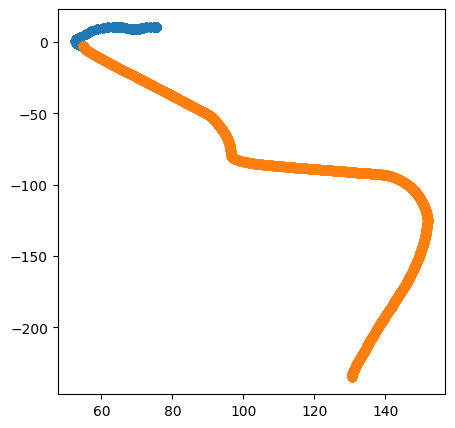

In [61]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
ax.scatter(sync_data["nav_x_gps"], sync_data["nav_y_gps"],label="NAV_GPS")
ax.scatter(sync_data["x_prop"], sync_data["y_prop"],label="NAV_GPS")

LOG_SEASCOUT-00_7_11_2024_____17_23_20


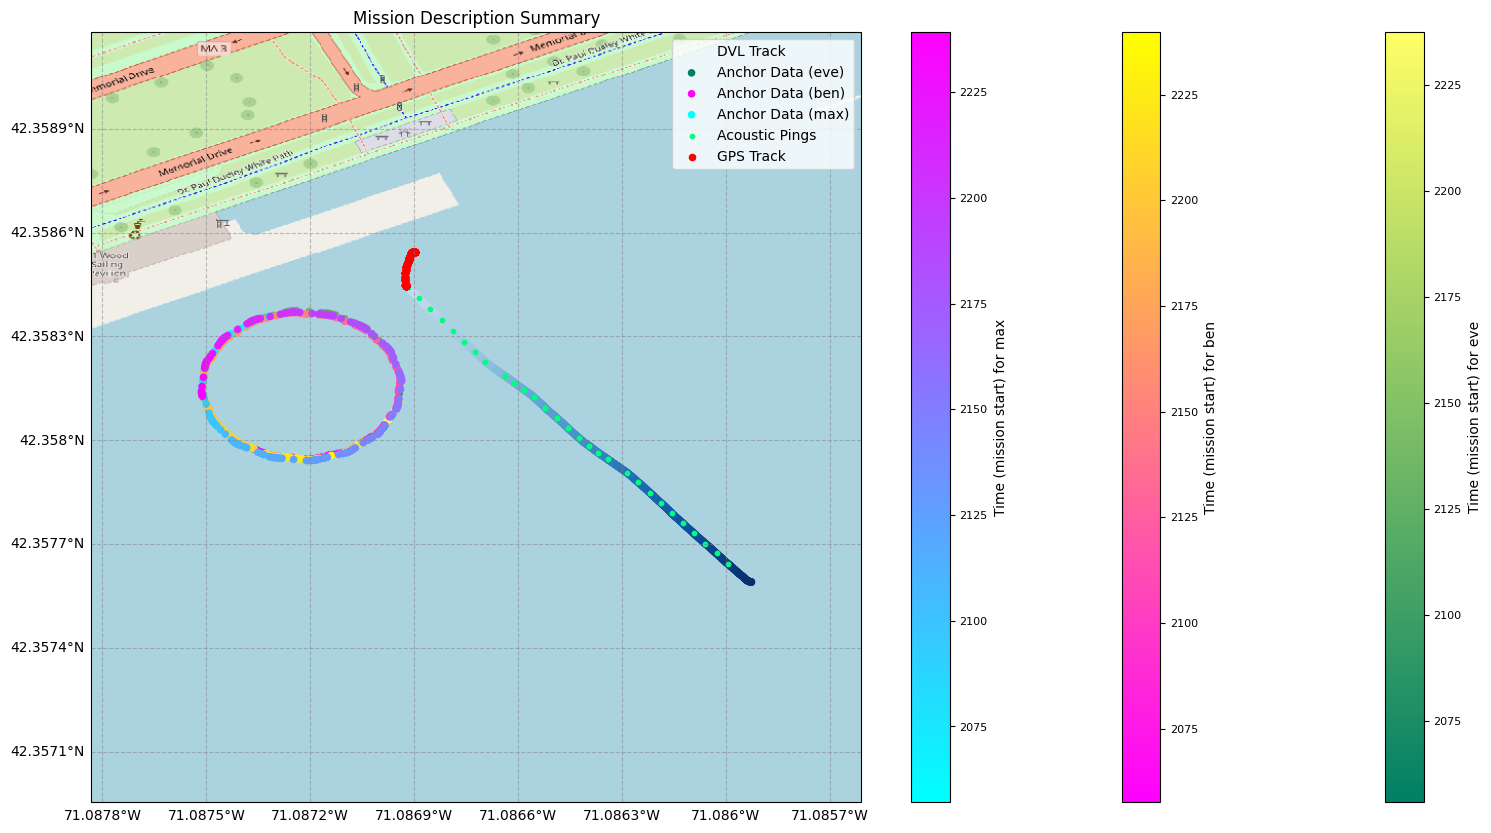

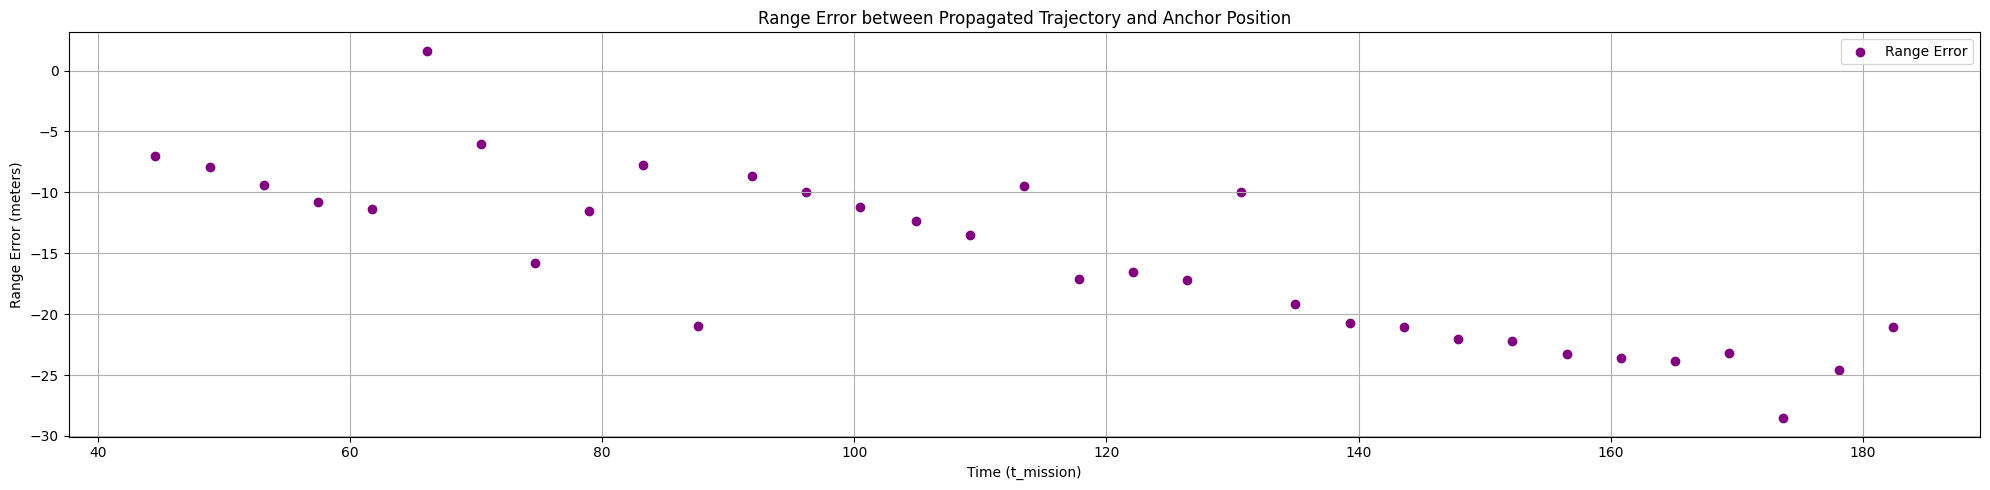

LOG_SEASCOUT-00_7_11_2024_____17_13_04


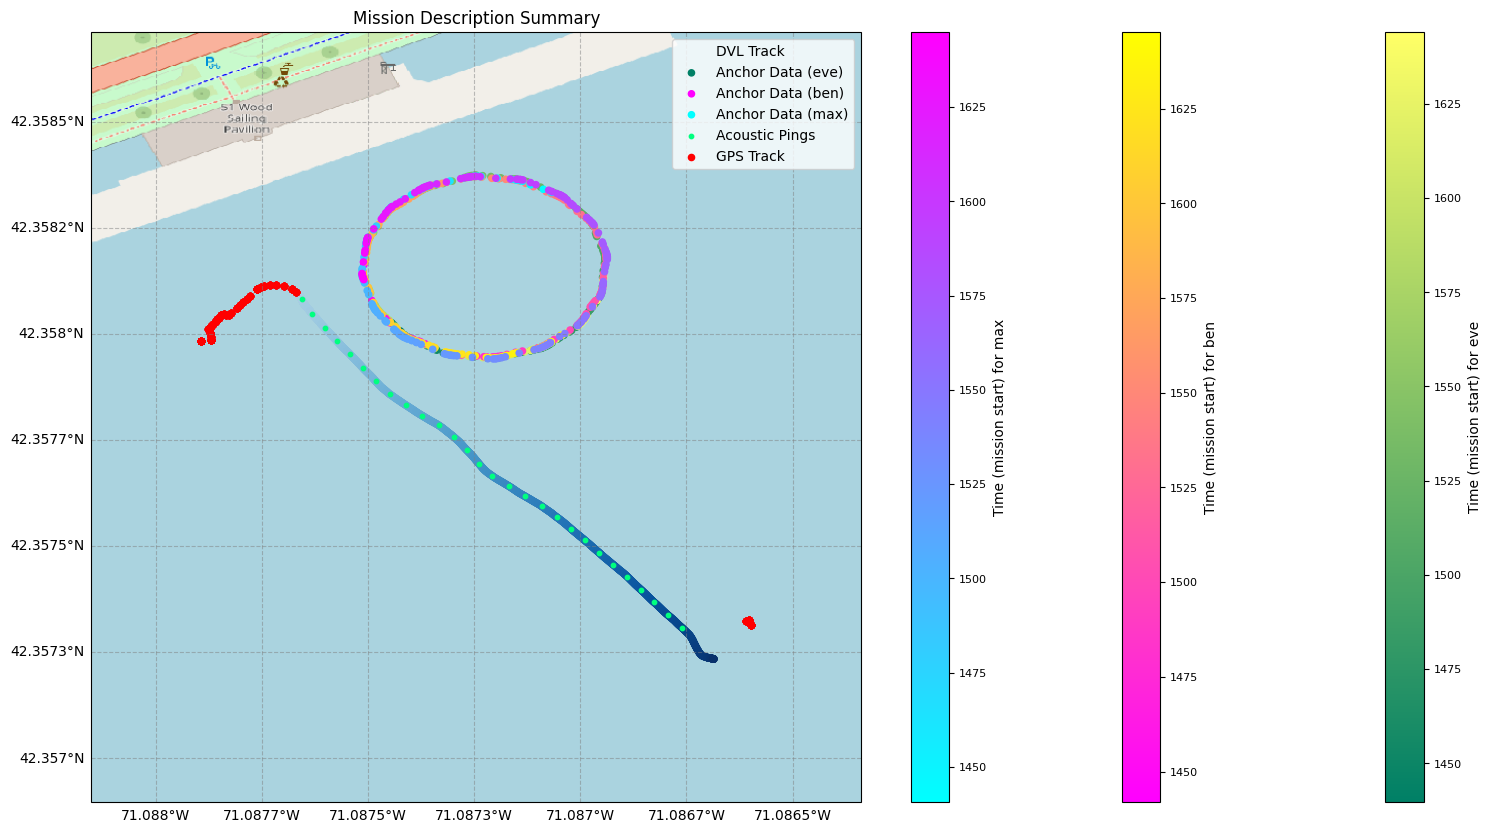

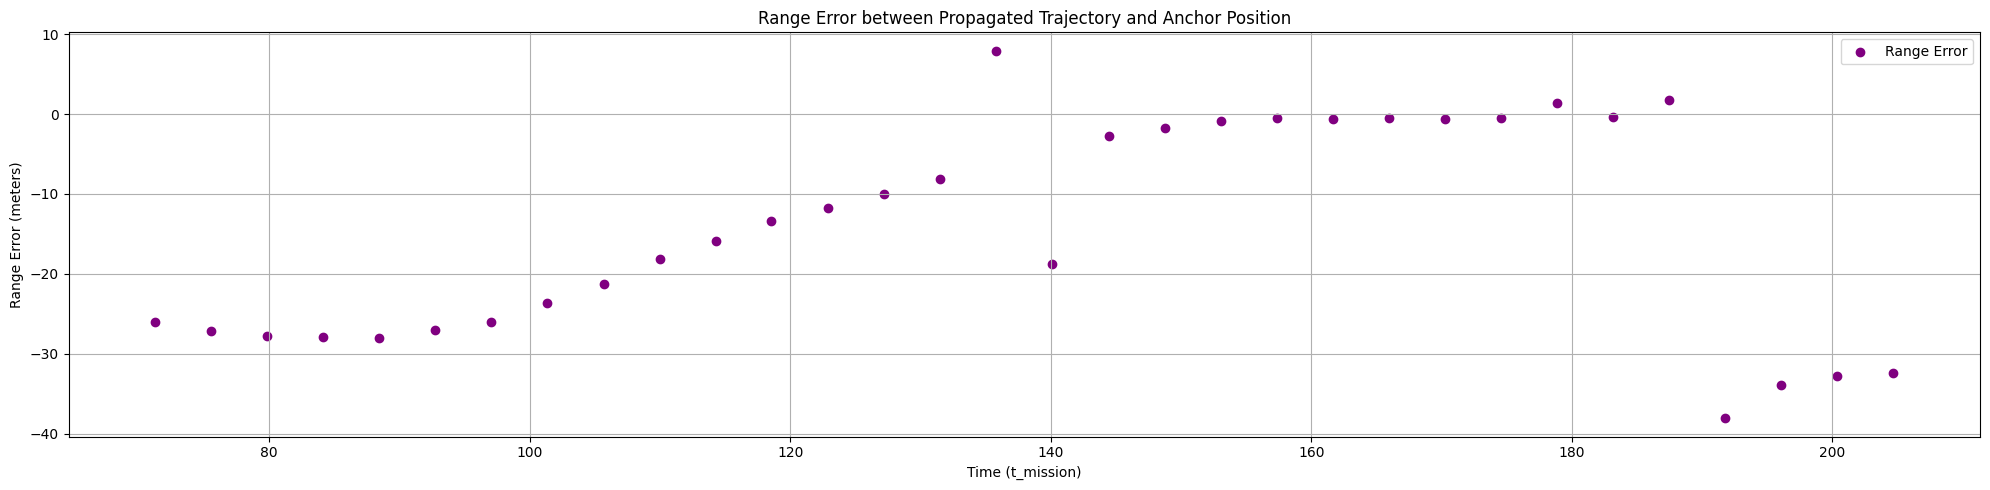

LOG_SEASCOUT-00_7_11_2024_____17_03_50


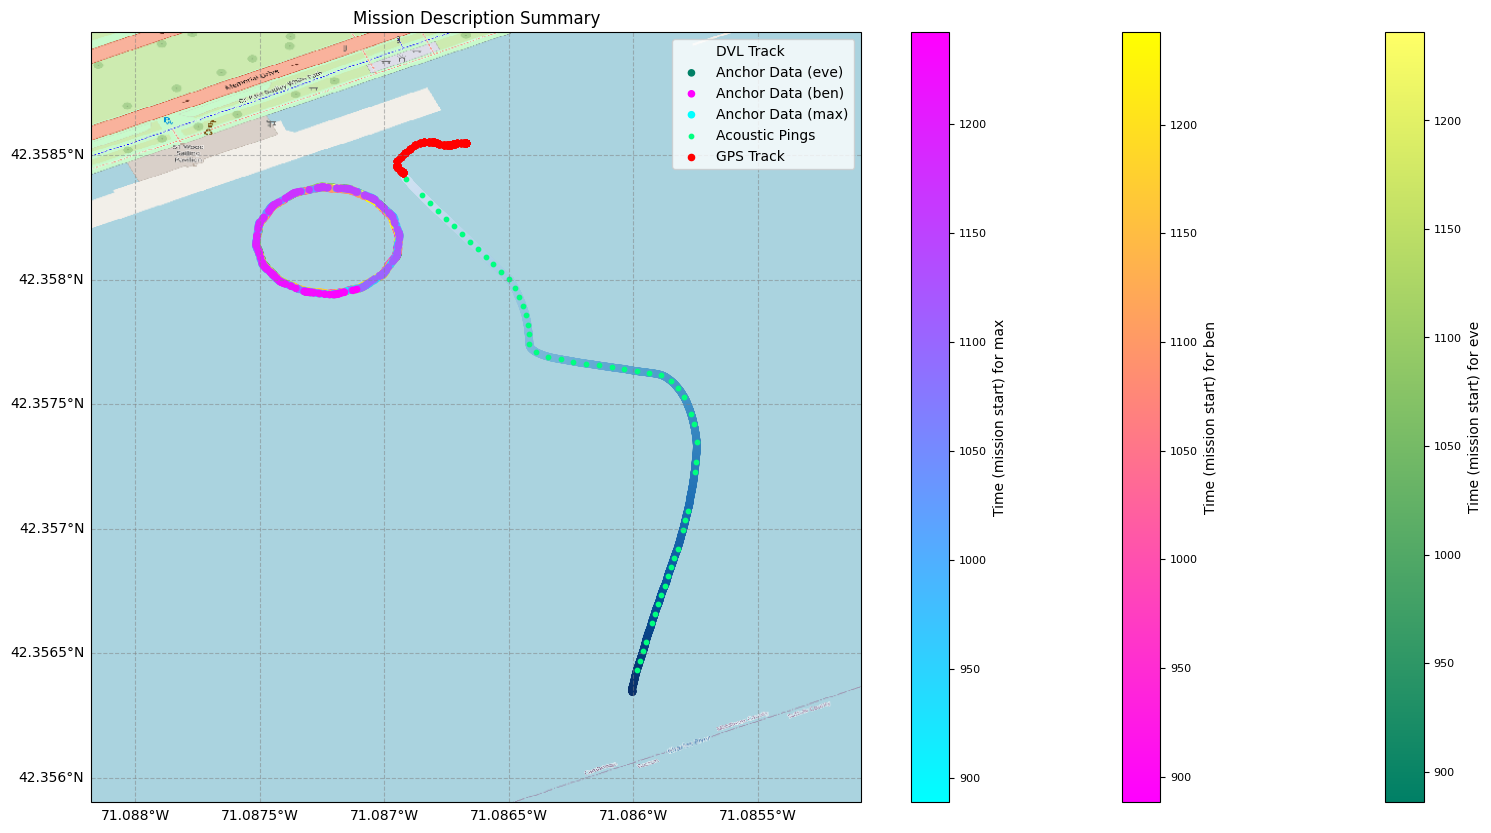

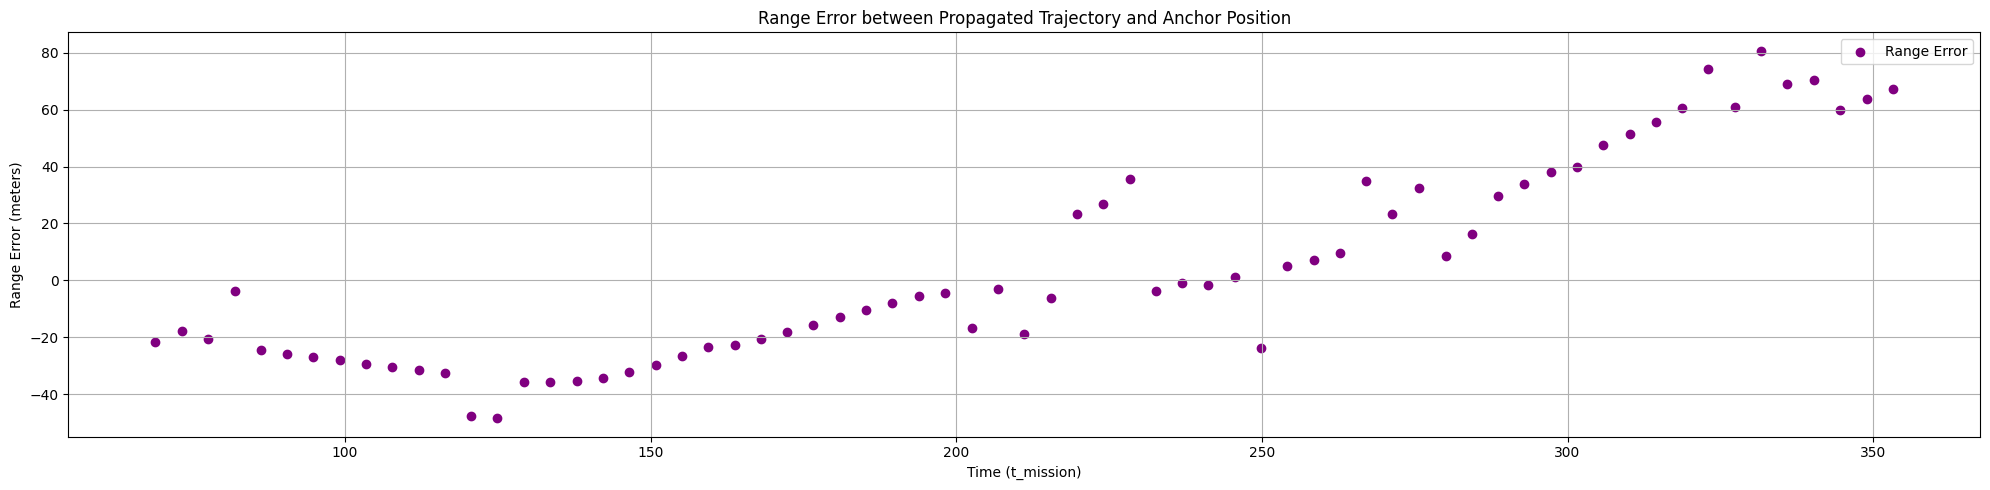

In [62]:
for k, v in filtered_data.items():
    if "SEASCOUT" in k:
        if k == "LOG_SEASCOUT-00_7_11_2024_____17_00_03":
            continue
        print(k)
        
        # Load IN_WATER and NAV_X/Y_GPS data
        in_water_df = pd.DataFrame(filtered_data[k]['data']['IN_WATER'], columns=['timestamp', 'status', 'sensor']).copy()
        in_water_time = in_water_df[in_water_df['status'] == 'true'].iloc[0]["timestamp"]
        nav_x_gps = pd.DataFrame(filtered_data[k]["data"]["NAV_X_GPS"], columns=['timestamps', 'nav_x_gps', 'src'])
        nav_y_gps = pd.DataFrame(filtered_data[k]["data"]["NAV_Y_GPS"], columns=['timestamps', 'nav_y_gps', 'src'])
        nav_depth = pd.DataFrame(filtered_data[k]["data"]["NAV_DEPTH"], columns=['timestamps', 'nav_depth', 'src'])

        # Convert timestamps and GPS values to float
        nav_x_gps[['timestamps', 'nav_x_gps']] = nav_x_gps[['timestamps', 'nav_x_gps']].astype(float)
        nav_y_gps[['timestamps', 'nav_y_gps']] = nav_y_gps[['timestamps', 'nav_y_gps']].astype(float)
        nav_x_gps.rename(columns={"timestamps": "time_since_epoch"}, inplace=True)
        nav_y_gps.rename(columns={"timestamps": "time_since_epoch"}, inplace=True)
        nav_x_gps.set_index("time_since_epoch", inplace=True)
        nav_y_gps.set_index("time_since_epoch", inplace=True)

        nav_x_gps.drop(columns=["src"], inplace=True)
        nav_y_gps.drop(columns=["src"], inplace=True)
        
        gps_data = nav_x_gps.copy()
        gps_data = gps_data.join(nav_y_gps, how="outer")
        gps_data = gps_data.ffill().dropna()

        mission_complete_time = filtered_data[k]['data']["MISSION_COMPLETE"][0][0]
        
        ahoi_range_data = filtered_data[k]["data_csv"]["ahoi_ranges"].copy()
        ahoi_range_data['time'] = pd.to_datetime(ahoi_range_data['time'], utc=False) + timedelta(hours=5)
        ahoi_range_data['time_since_epoch'] = ahoi_range_data['time'].apply(lambda x: x.timestamp()) 
        
        # Synchronize and process data
        csv_files = filtered_data[k]["data_csv"]
        sync_data, ahoi_ranging = synchronize_data(csv_files, ahoi_range_data, in_water_time, mission_complete_time, gps_data)
        sync_data = propagate_dvl_positions(sync_data)
        sync_data = add_geodetic_positions(sync_data)

        # Get start and end times from synchronized data
        sync_start_time = sync_data['time'].min()
        sync_end_time = sync_data['time'].max()

        # Process anchor dataframes for multiple vehicles
        anchor_dataframes_trimmed = {}
        for vname, anchor_df in anchor_dataframes.items():
            anchor_df_trimmed = anchor_df[(anchor_df['time'] >= sync_start_time) & (anchor_df['time'] <= sync_end_time)]
            anchor_dataframes_trimmed[vname] = anchor_df_trimmed

        # Plot the GPS and DVL track with anchor data for multiple vehicles
        mission_summary_plot(sync_data, anchor_dataframes_trimmed, ahoi_ranging)